In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time

In [5]:
# Problem 1
df1 = pd.read_csv('HealthProb1.csv')

# get explanatory and response variables separate
X1 = df1.drop(columns=['HealthCondition'])
y1 = df1['HealthCondition']

# 3.1, first split into training and validation
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, test_size=0.2, random_state = 5104)
df1_train = X1_train.copy()
df1_train['HealthCondition'] = y1_train
df1_val = X1_val.copy()
df1_val['HealthCondition'] = y1_val

df1_train.to_csv('Prob1_train.csv', index=False)
df1_val.to_csv('Prob1_val.csv', index=False)

In [3]:
# Problem 1 - Decision Tree

ccp_alpha_vals = [0, 0.005, 0.010, 0.015, 0.020]

startTime = time.time()
kf = KFold(n_splits=5, shuffle=True, random_state=5104)
cv_means = []

for alpha in ccp_alpha_vals:
    dtc1 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=alpha, random_state=5104)
    scores = cross_val_score(dtc1, X1_train, y1_train, cv=kf, scoring='recall')
    # using recall as performance metric for each model because the cost of a false negative is higher than overall accuracy or a false positive
    # since false negative would mean potentially leaving a patient at risk of a health condition alone/untreated
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average recall metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was ccp_alpha = ' + str(ccp_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(ccp_alpha_vals, cv_means)
plt.xlabel('Cost Complexity Alpha')
plt.ylabel('Mean CV Recall')
plt.title('Decision Tree CV Performance')
plt.show()

for alpha value: 0, average recall metric measure value among the k=5 folds was 0.7041163647116424


KeyboardInterrupt: 

In [ ]:
# Problem 1 - ANN

alpha_vals =  [0.00001, 0.0001, 0.001, 0.01, 0.1]
startTime = time.time()
kf = KFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for alpha in alpha_vals:
    ann1 = MLPClassifier(activation = 'relu', alpha=alpha, random_state=5104, max_iter = 200)
    scores = cross_val_score(ann1, X1_train, y1_train, cv=kf, scoring='neg_log_loss')
    # using logloss/cross entropy loss as performance metric
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average negative logloss metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was alpha = ' + str(alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(alpha_vals, cv_means)
plt.xlabel('L2 Regularization Alpha')
plt.ylabel('Mean Negative CV LogLoss')
plt.title('Multi Level Perceptron ANN CV Performance')
plt.show()

In [ ]:
# Problem 1 - SVM

c_vals = [0.001, 0.01, 0.1, 1, 10]
startTime = time.time()
kf = KFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for c in c_vals:
    svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=c))])
    svm1 = SVC(C=c)
    scores = cross_val_score(svm1, X1_train, y1_train, cv=kf, scoring='accuracy')
    # using accuracy as performance metric
    cv_means.append(np.mean(scores))
    print('for C value: ' + str(c)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was C = ' + str(c_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(c_vals, cv_means)
plt.xlabel('C Value')
plt.ylabel('Mean CV Accuracy')
plt.title('SVM CV Performance')
plt.show()

folds done


folds done
for number of trees: 25, average recall metric measure value among the k=5 folds was 0.8143722619682997
for number of trees: 50, average recall metric measure value among the k=5 folds was 0.8150830079084985
for number of trees: 100, average recall metric measure value among the k=5 folds was 0.8203922943611415
for number of trees: 200, average recall metric measure value among the k=5 folds was 0.8222637728340334
for number of trees: 300, average recall metric measure value among the k=5 folds was 0.8235401247050037
[0.8143722619682997, 0.8150830079084985, 0.8203922943611415, 0.8222637728340334, 0.8235401247050037]
Best hyperparameter value was number of trees = 300 with performance metric value of 0.8235401247050037
Runtime: 353.35487699508667


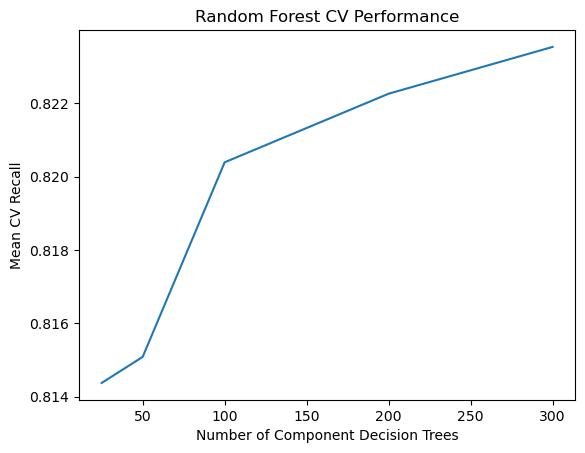

In [6]:
# Problem 1 - Random Forest

num_trees_vals = [25, 50, 100, 200, 300]
startTime = time.time()
kf = KFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for tree_num in num_trees_vals:
    rfc1 = RandomForestClassifier(criterion = 'gini', n_estimators = tree_num)
    scores = cross_val_score(rfc1, X1_train, y1_train, cv=kf, scoring='recall')
    # using recall as performance metric (same reasoning as that for decision tree)
    cv_means.append(np.mean(scores))
    print('for number of trees: ' + str(tree_num)+', average recall metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was number of trees = ' + str(num_trees_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(num_trees_vals, cv_means)
plt.xlabel('Number of Component Decision Trees')
plt.ylabel('Mean CV Recall')
plt.title('Random Forest CV Performance')
plt.show()

In [9]:
# Problem 2
df2 = pd.read_csv('HealthProb2.csv')

# get explanatory and response variables separate
X2 = df2.drop(columns=['RiskLevel'])
y2 = df2['RiskLevel']

# 4.1, first split into training and validation
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.2, random_state = 5104)
df2_train = X2_train.copy()
df2_train['RiskLevel'] = y2_train
df2_val = X2_val.copy()
df2_val['RiskLevel'] = y2_val

df2_train.to_csv('Prob2_train.csv', index=False)
df2_val.to_csv('Prob2_val.csv', index=False)

In [12]:
# Problem 2 - Decision Tree

ccp_alpha_vals = [0, 0.005, 0.010, 0.015, 0.020]

startTime = time.time()
kf = KFold(n_splits=5, shuffle=True, random_state=5104)
cv_means = []

for alpha in ccp_alpha_vals:
    dtc2 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=alpha, random_state=5104)
    scores = cross_val_score(dtc2, X2_train, y2_train, cv=kf, scoring='accuracy')
    # using accuracy instead of recall since we don't only have a positive and negative class anymore
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was ccp_alpha = ' + str(ccp_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(ccp_alpha_vals, cv_means)
plt.xlabel('Cost Complexity Alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('Decision Tree CV Performance')
plt.show()

for alpha value: 0, average accuracy metric measure value among the k=5 folds was 0.517260894552704
for alpha value: 0.005, average accuracy metric measure value among the k=5 folds was 0.5891674552886774
for alpha value: 0.01, average accuracy metric measure value among the k=5 folds was 0.5855556168201396
for alpha value: 0.015, average accuracy metric measure value among the k=5 folds was 0.5855556168201396


KeyboardInterrupt: 

folds done
for number of trees: 25, average accuracy metric measure value among the k=5 folds was 0.5865657569202918
for number of trees: 50, average accuracy metric measure value among the k=5 folds was 0.59206972697581
for number of trees: 100, average accuracy metric measure value among the k=5 folds was 0.5951543379846862
for number of trees: 200, average accuracy metric measure value among the k=5 folds was 0.597356906760915
for number of trees: 300, average accuracy metric measure value among the k=5 folds was 0.5976574852999252
[0.5865657569202918, 0.59206972697581, 0.5951543379846862, 0.597356906760915, 0.5976574852999252]
Best hyperparameter value was number of trees = 300 with performance metric value of 0.5976574852999252
Runtime: 417.7334110736847


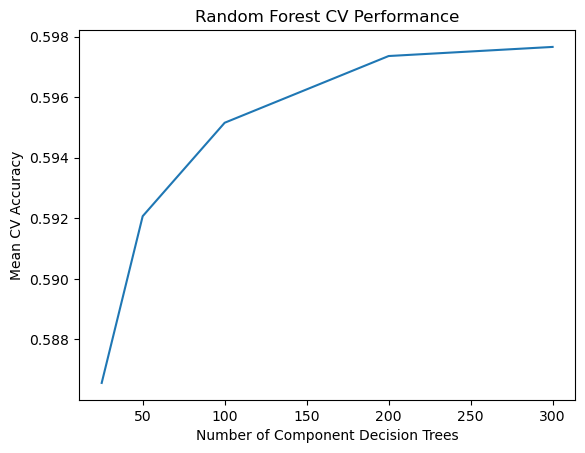

In [13]:
# Problem 2 - Random Forest

num_trees_vals = [25, 50, 100, 200, 300]
startTime = time.time()
kf = KFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for tree_num in num_trees_vals:
    rfc2 = RandomForestClassifier(criterion = 'gini', n_estimators = tree_num)
    scores = cross_val_score(rfc2, X2_train, y2_train, cv=kf, scoring='accuracy')
    # using recall as performance metric (same reasoning as that for decision tree)
    cv_means.append(np.mean(scores))
    print('for number of trees: ' + str(tree_num)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was number of trees = ' + str(num_trees_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(num_trees_vals, cv_means)
plt.xlabel('Number of Component Decision Trees')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest CV Performance')
plt.show()